# EDA

## Men's Volleyball National League 2023 <img src="volleyball.png" width=50 height=50>

In [1]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns
sns.set_style("darkgrid")

### importing dataset

In [2]:
df = pd.read_csv("VNL2023.csv")

### inspecting

In [3]:
df.head()

,Player,Country,Age,Attack,Block,Serve,Set,Dig,Receive,Position
0,Ichikawa Yuki,Japan,28,15.80,1.13,1.40,0.07,4.80,5.60,OH
1,Romano Yuri,Italy,26,12.33,1.07,1.47,0.00,3.87,0.00,OP
2,Abdel-Aziz Nimir,Nederland,31,15.33,0.67,2.08,0.00,3.17,0.25,OP
3,Herrera Jaime Jesus,Cuba,28,15.00,0.92,1.75,0.00,3.33,0.17,OP
4,Takahashi Ran,Japan,22,11.53,0.67,1.00,0.07,6.40,5.07,OH


In [4]:
df.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 131 entries, 0 to 130
Data columns (total 10 columns):
 #   Column    Non-Null Count  Dtype  
---  ------    --------------  -----  
 0   Player    131 non-null    object 
 1   Country   131 non-null    object 
 2   Age       131 non-null    int64  
 3   Attack    131 non-null    float64
 4   Block     131 non-null    float64
 5   Serve     131 non-null    float64
 6   Set       131 non-null    float64
 7   Dig       131 non-null    float64
 8   Receive   131 non-null    float64
 9   Position  131 non-null    object 
dtypes: float64(6), int64(1), object(3)
memory usage: 10.4+ KB


In [7]:
df.shape

(131, 10)

- before doing EDA, lets see if there are missing, duplicated

In [5]:
df.isnull().sum()

Player      0
Country     0
Age         0
Attack      0
Block       0
Serve       0
Set         0
Dig         0
Receive     0
Position    0
dtype: int64

In [6]:
df.duplicated().sum()

np.int64(0)

In [8]:
df.describe()

,Age,Attack,Block,Serve,Set,Dig,Receive
count,131.000000,131.000000,131.000000,131.000000,131.000000,131.000000,131.000000
mean,27.809160,5.642672,0.845573,0.535802,2.192595,3.428397,1.684198
std,4.186268,4.256229,0.700896,0.454346,6.031587,2.077823,1.989939
min,19.000000,0.000000,0.000000,0.000000,0.000000,0.530000,0.000000
25%,25.000000,2.800000,0.370000,0.240000,0.000000,1.920000,0.000000
50%,27.000000,5.170000,0.690000,0.420000,0.000000,3.000000,0.330000
75%,30.000000,8.600000,1.140000,0.760000,0.000000,4.510000,3.385000
max,41.000000,15.800000,4.080000,2.080000,26.890000,11.440000,6.690000


Age           Axes(0.125,0.53;0.133621x0.35)
Attack     Axes(0.285345,0.53;0.133621x0.35)
Block       Axes(0.44569,0.53;0.133621x0.35)
Serve      Axes(0.606034,0.53;0.133621x0.35)
Set        Axes(0.766379,0.53;0.133621x0.35)
Dig           Axes(0.125,0.11;0.133621x0.35)
Receive    Axes(0.285345,0.11;0.133621x0.35)
dtype: object

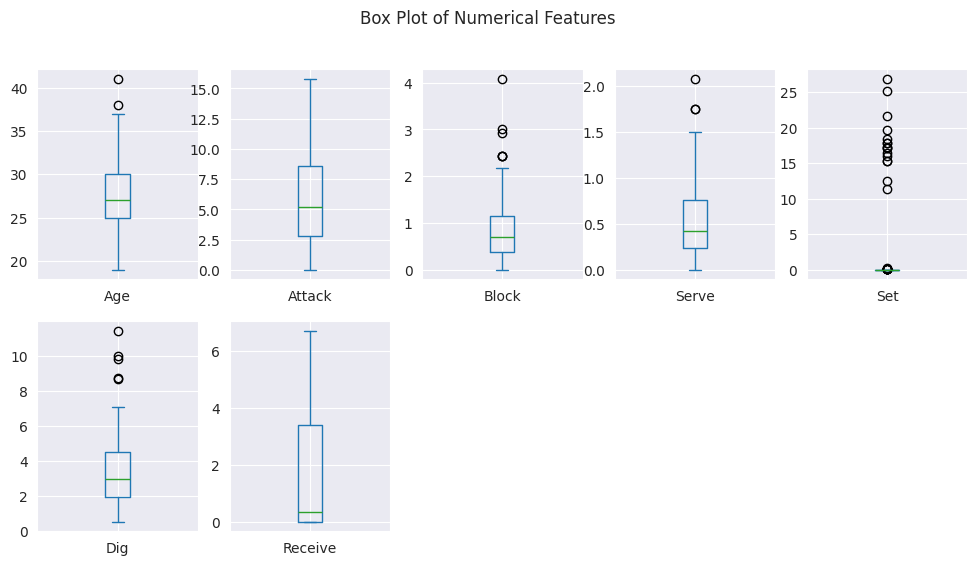

In [12]:
df.plot(kind="box", figsize=(12, 6), title="Box Plot of Numerical Features", subplots=True, layout=(2, 5), sharex=False, sharey=False)

`that outliers is good show us the professional`

#### correlation

<Axes: >

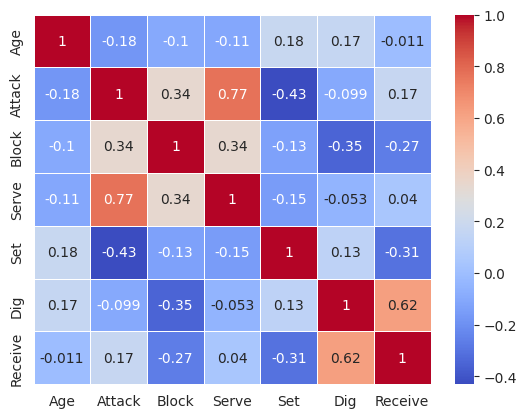

In [15]:
sns.heatmap(df.select_dtypes(include="number").corr(), annot=True, cmap="coolwarm", linewidths=0.5)

<h5>relation note: </h5>

- Dig & Receive
- Serve & Attack

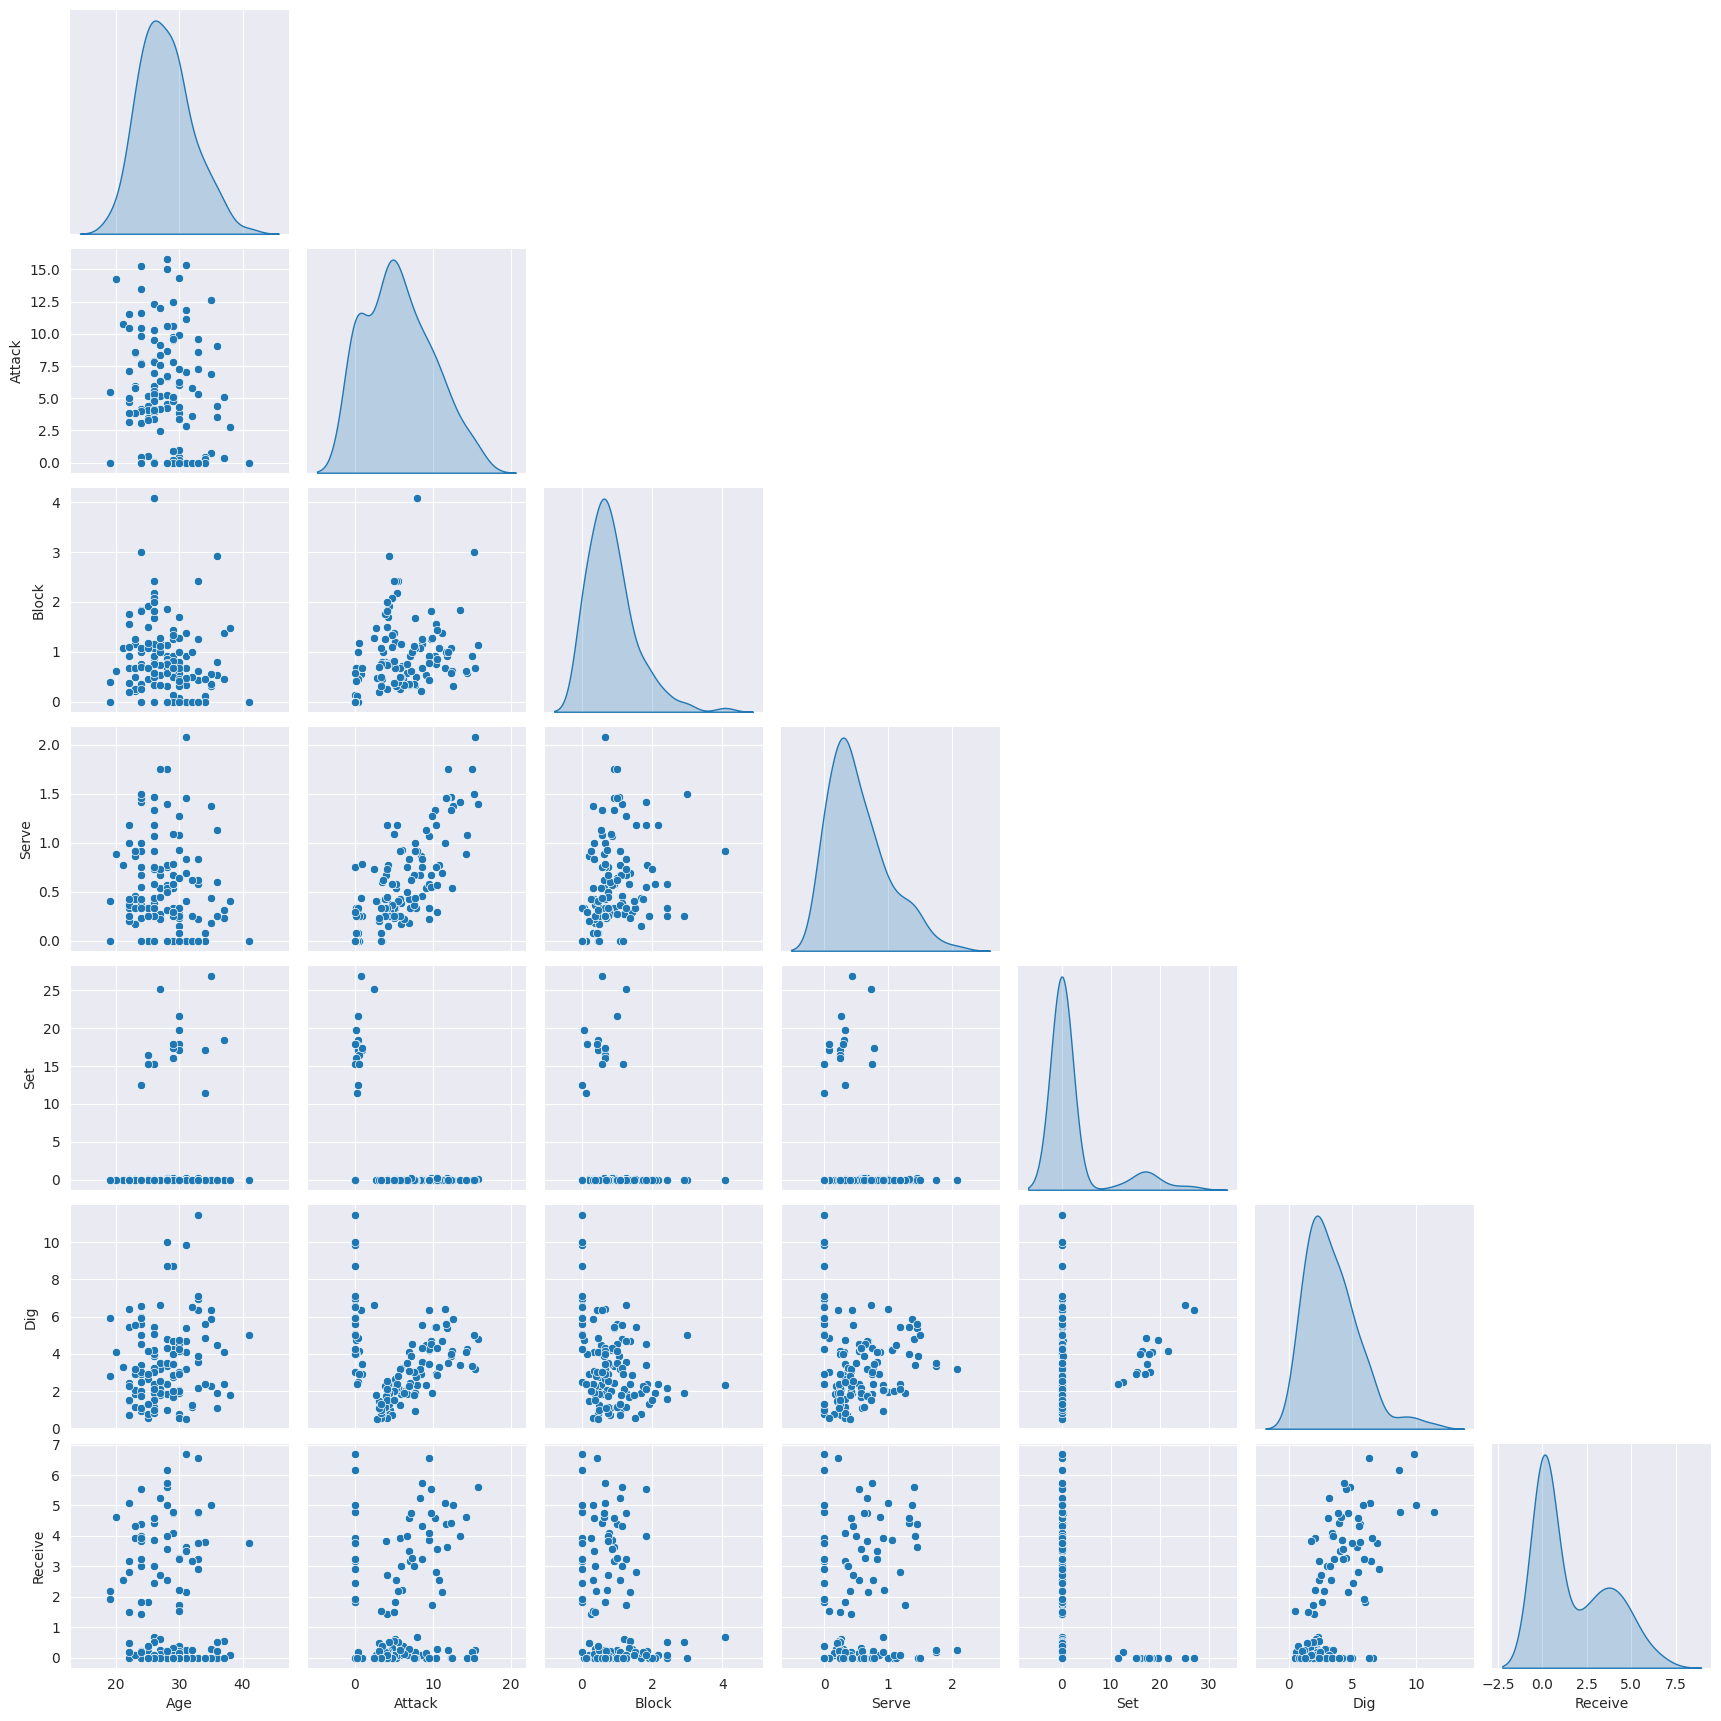

In [16]:
sns.pairplot(df.select_dtypes(include="number"), diag_kind="kde", corner=True)

In [18]:
df.head()

,Player,Country,Age,Attack,Block,Serve,Set,Dig,Receive,Position
0,Ichikawa Yuki,Japan,28,15.80,1.13,1.40,0.07,4.80,5.60,OH
1,Romano Yuri,Italy,26,12.33,1.07,1.47,0.00,3.87,0.00,OP
2,Abdel-Aziz Nimir,Nederland,31,15.33,0.67,2.08,0.00,3.17,0.25,OP
3,Herrera Jaime Jesus,Cuba,28,15.00,0.92,1.75,0.00,3.33,0.17,OP
4,Takahashi Ran,Japan,22,11.53,0.67,1.00,0.07,6.40,5.07,OH


<h5>Data visualization</h5>

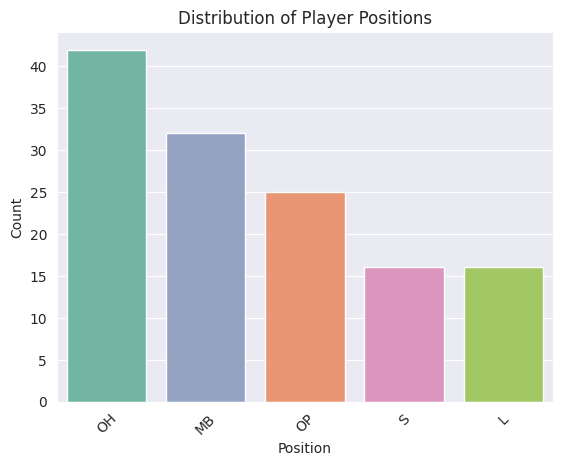

In [22]:
sns.countplot(data=df, x="Position", order=df["Position"].value_counts().index, hue="Position", palette="Set2")
plt.title("Distribution of Player Positions")
plt.xlabel("Position")
plt.ylabel("Count")
plt.xticks(rotation=45)
plt.show()

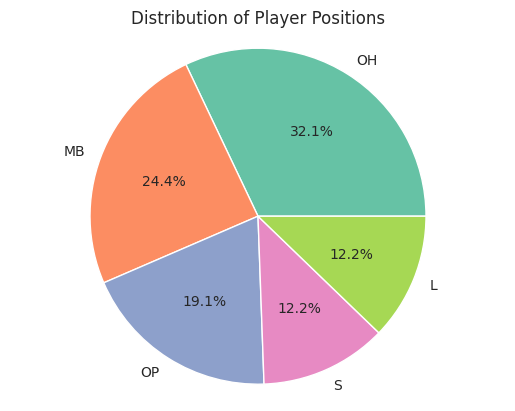

In [26]:
plt.pie(df["Position"].value_counts(), labels=df["Position"].value_counts().index, autopct="%1.1f%%", colors=sns.color_palette("Set2"))
plt.title("Distribution of Player Positions")
plt.axis("equal")
plt.show()


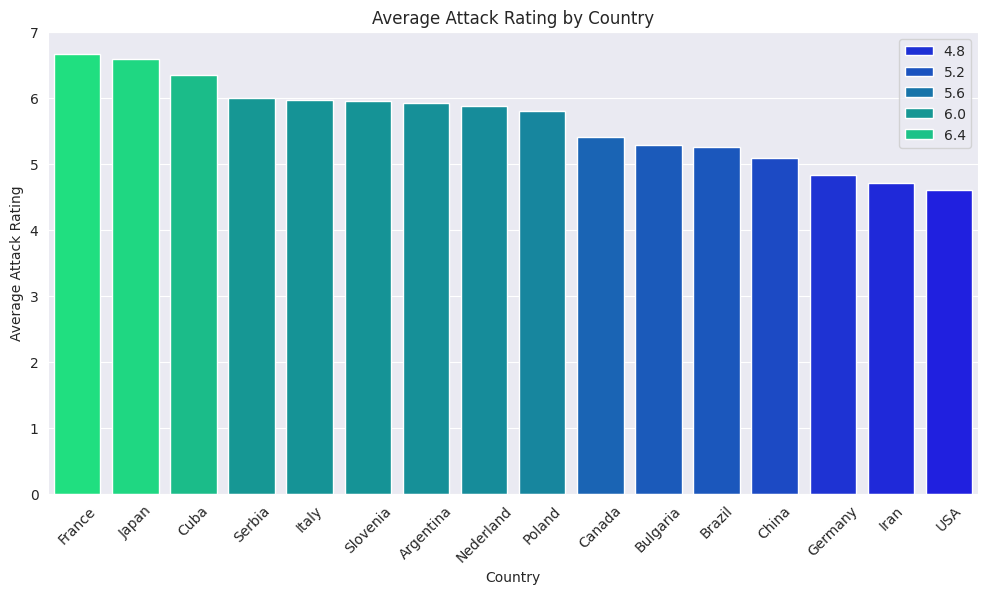

In [33]:
avrg_attack_by_country = df.groupby("Country")["Attack"].mean().sort_values(ascending=False)
plt.figure(figsize=(12, 6))
sns.barplot(x=avrg_attack_by_country.index, y=avrg_attack_by_country.values, hue=avrg_attack_by_country.values, palette="winter")
plt.title("Average Attack Rating by Country")
plt.xlabel("Country")
plt.ylabel("Average Attack Rating")
plt.xticks(rotation=45)
plt.show()

/tmp/ipykernel_16629/3731814969.py:4: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `x` variable to `hue` and set `legend=False` for the same effect.

  sns.barplot(x=top_attack_players["Player"], y=top_attack_players["Attack"], palette="viridis")


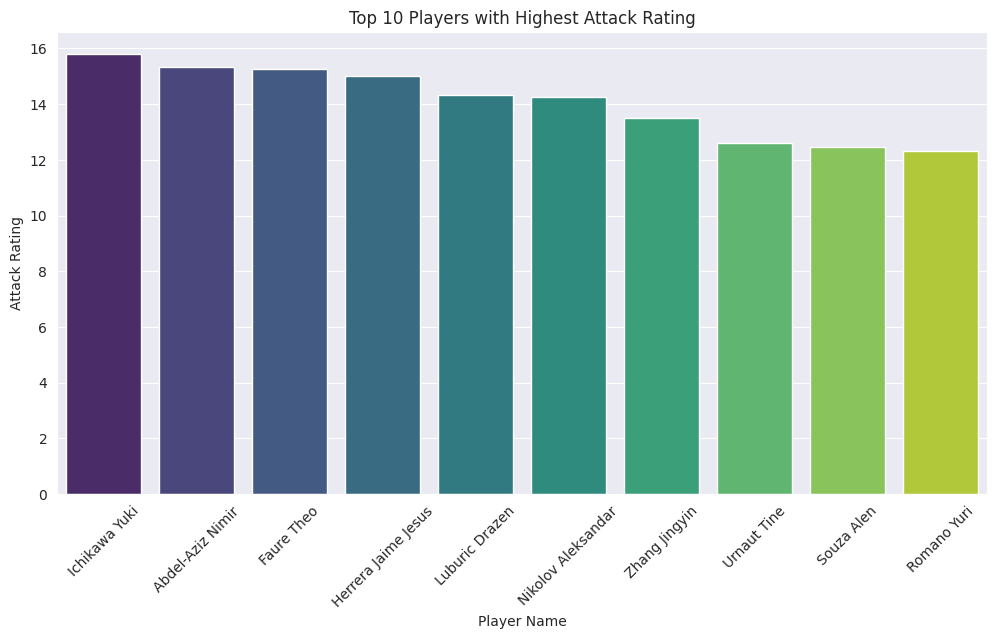

In [38]:
# get top 10 players with highest attack rating
top_attack_players = df.sort_values(by="Attack", ascending=False).head(10)
plt.figure(figsize=(12, 6))
sns.barplot(x=top_attack_players["Player"], y=top_attack_players["Attack"], palette="viridis")
plt.title("Top 10 Players with Highest Attack Rating")
plt.xlabel("Player Name")
plt.ylabel("Attack Rating")
plt.xticks(rotation=45)
plt.show()